In [1]:
library(DynamicPGS)
Sys.setenv(
  OMP_NUM_THREADS = "1",
  OPENBLAS_NUM_THREADS = "1",
  MKL_NUM_THREADS = "1",
  VECLIB_MAXIMUM_THREADS = "1"
)

DynamicPGS object
Number of samples: 24946
Number of individuals: 3000
Max family size: 3
Support: 0 to 54
Covariates:
          degrees_of_freedom
Intercept                  1
pc1                        1
pc2                        1
sex                        2

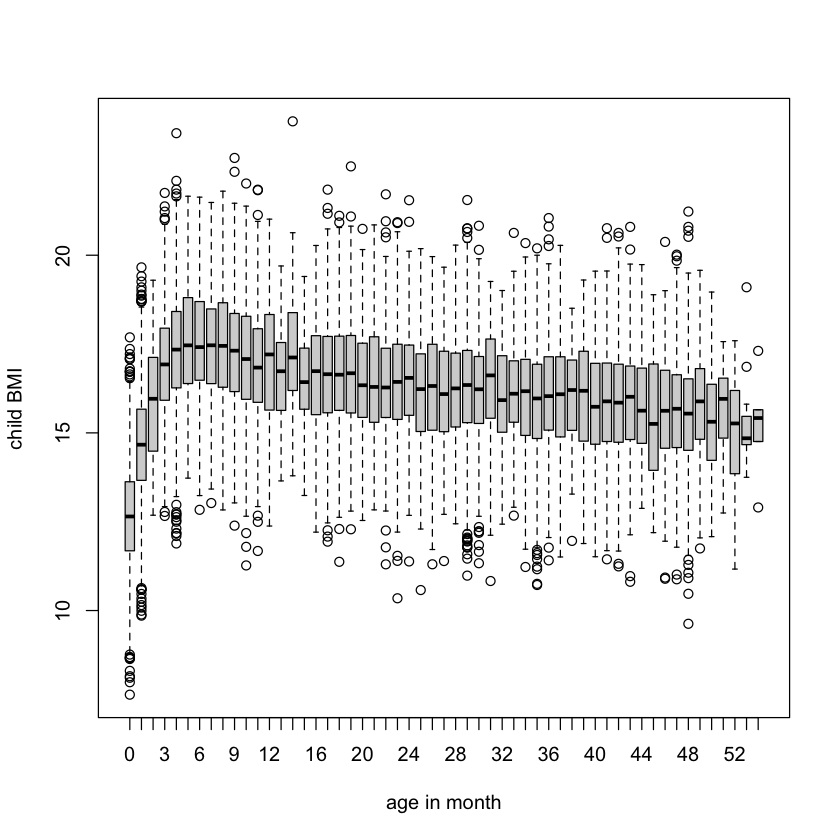

In [2]:
# Creating mock DynamicPGS data object
adata = getData("MockData/phenotype.tsv",
                "MockData/covariates.tsv",
                "MockData/king.kin0",
                inducing_points=0:11*5)
adata
boxplot(adata$y~adata$x, xlab="age in month", ylab="child BMI")

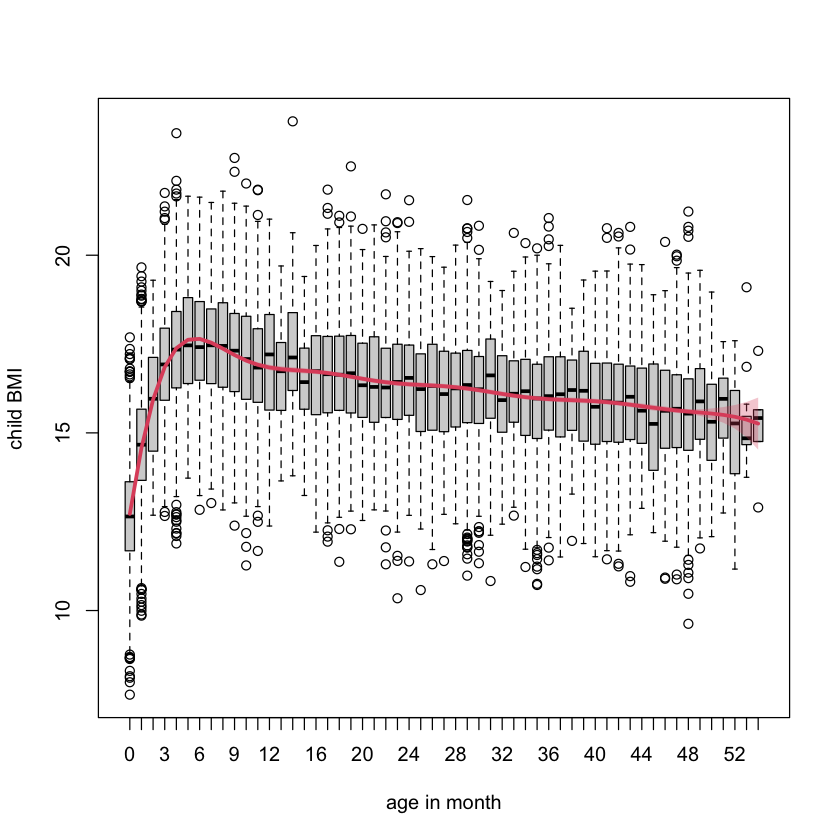

In [3]:
# Fit the population-level GP model
adata = GPReg1(adata) # takes few mins
# plotting the fitted curve for the 1st individual
plot(adata, xlab="age in month", ylab="child BMI")

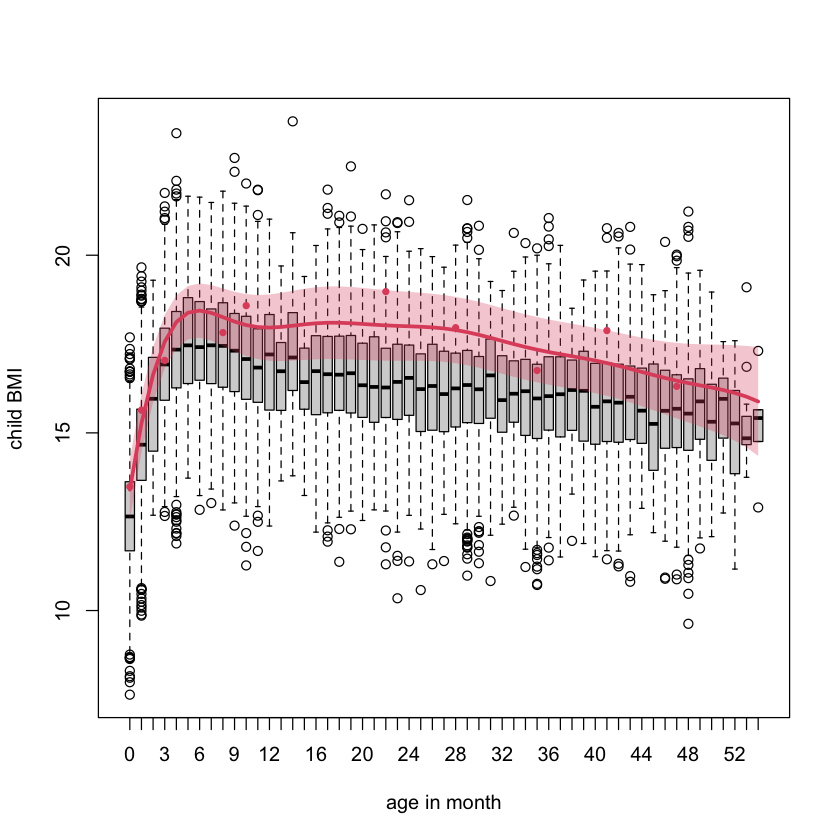

In [4]:
# Fit individual-level dynamic deviation components
adata = GPReg2(adata, ncore=12) # takes few mins
# plotting the fitted curve for the 1st individual
plot(adata, i=1, xlab="age in month", ylab="child BMI")

In [5]:
# Prep genotype dosage matrix
L = 238 # the number of true dynamic associations simulated in the mock data
G = rbind(
    getDoseFromVCF("MockData/dose.vcf.gz",reg=paste0("0:1-",1000-L)), # variants under null hypothesis
    getDoseFromVCF("MockData/dose.vcf.gz",reg=paste0("1:1-",L)))      # variants under althernative hypothesis
# variant x sample table
G[c(1:5,763:767),1:10]
# the row names follow CHR:POS:ALT:REF format
# chromosome 0 stands for variants observed under the null hypothesis
# chromosome 1 stands for variants observed under the alternative hypothesis
# chromosomal position was set 1...L

variants read: 762 | parsed lines: 762
Finished: read variants=762
variants read: 238 | parsed lines: 238
Finished: read variants=238


,ID000002,ID002256,ID002417,ID000004,ID002370,ID000007,ID000404,ID000887,ID000009,ID000329
0:1:A:C,0,0,0,0,0,1,1,0,0,0
0:2:A:C,0,0,1,0,2,0,2,1,0,0
0:3:A:C,0,0,1,2,1,1,2,2,0,0
0:4:A:C,1,0,0,1,1,1,0,1,2,2
0:5:A:C,2,2,2,2,1,1,2,2,1,2
1:1:A:C,1,0,1,0,0,1,0,0,0,0
1:2:A:C,0,0,2,0,0,0,0,1,1,1
1:3:A:C,0,1,0,0,0,0,0,1,0,0
1:4:A:C,0,0,1,1,2,2,2,1,1,2
1:5:A:C,0,1,0,0,1,0,0,1,1,0


In [6]:
# Dynamic association mapping
# For genome-wide association mapping, set ncore = 1 and submit array jobs
# in parallel for different chunks of G.
adata = getP(adata,G,ncore=12)

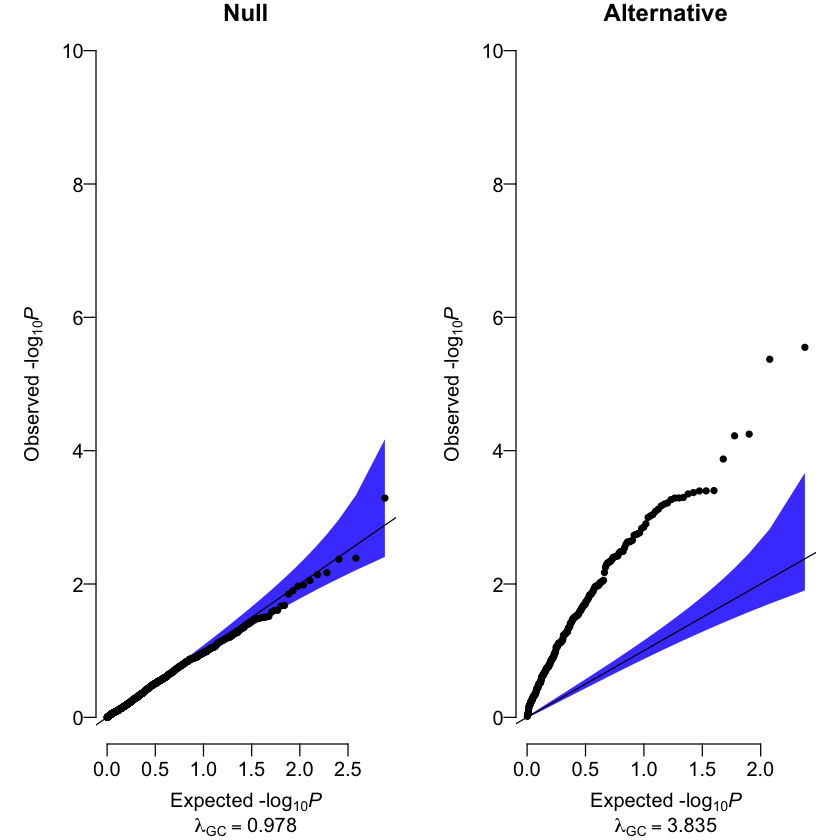

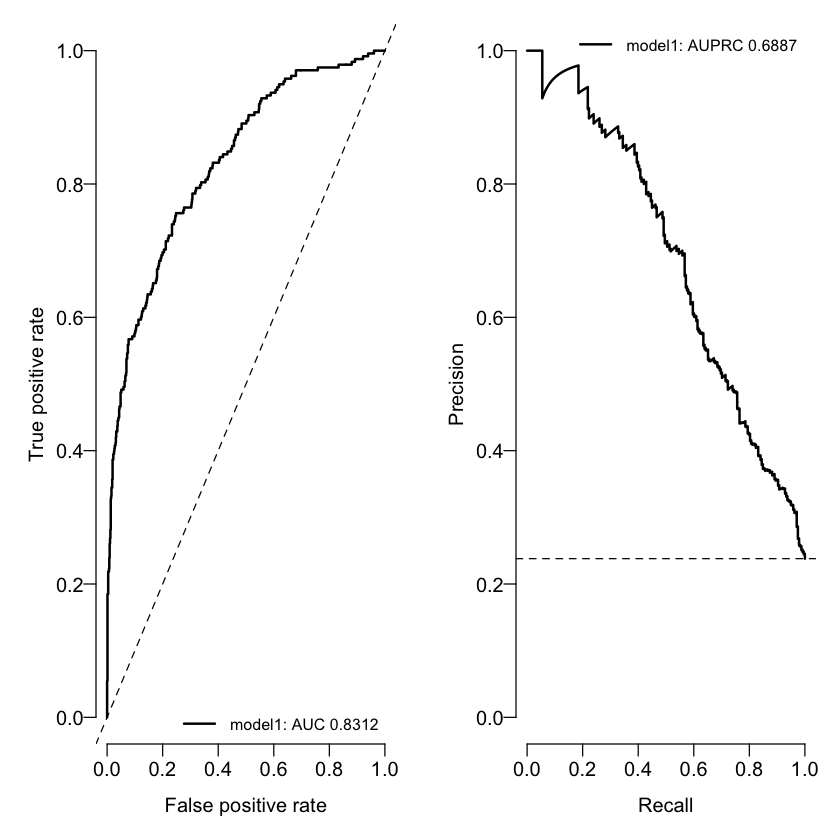

In [7]:
# check the statistical calibration using QQ-plot
par(mfcol=c(1,2))
ppplot(adata$pval[1:(1000-L)],main="Null")
ppplot(tail(adata$pval,L),main="Alternative")
# ROC and Precision-Recall curve
isalt=rep(0:1,c(1000-L, L))
plotROCandPRC(adata$pval, isalt)

       isalt
          0   1
  FALSE 761 216
  TRUE    1  22

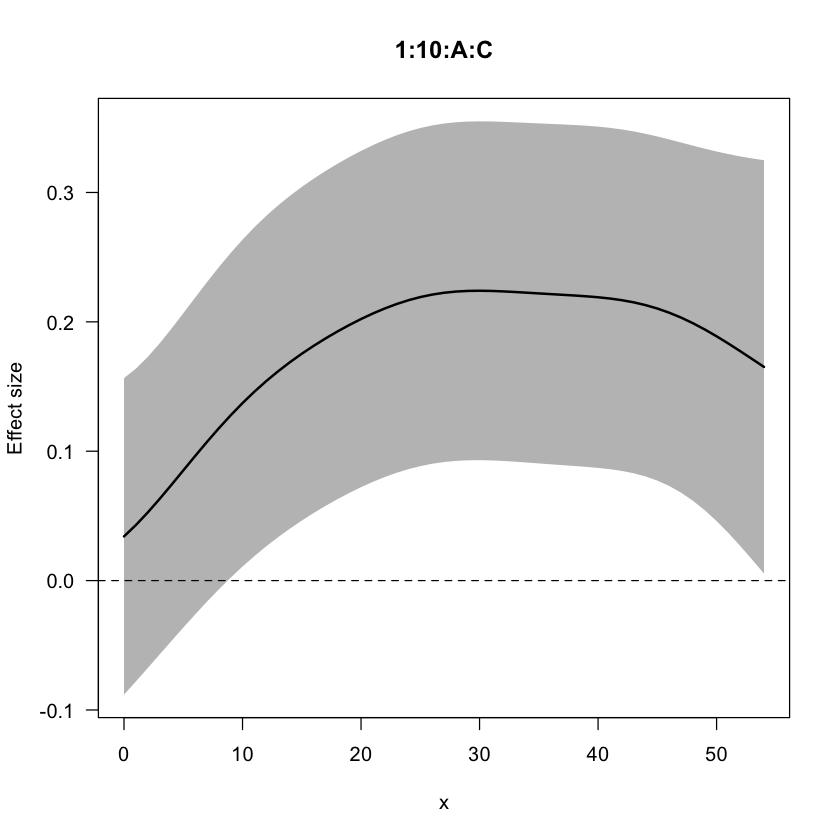

In [8]:
#　hypothesis testing and comparison to the true scenario
qval = p.adjust(adata$pval,meth="BH")
table(qval<0.05, isalt) # FDR = 1 in 23 (=4.3%)
# Estimating the QTL effect sizes for positive variants for dynamic PGC computation
adata_positive = getP(adata, G[qval<0.05,], Beta=T, Sinv=T, ncore=12)
# plotting e.g., the effect size for the 2nd variant
plotEffectSize(adata_positive,rownames(G)[qval<0.05][2])

In [38]:
# stripping individual data and parameters so that the PGS model can be public
pdata = getPublicData(adata_positive)
# make sure rownames are compatible
rownames(pdata$Beta)==rownames(G[qval<0.05,])
rownames(pdata$Beta)==names(adata_positive$allele_frequency)

# computing the dynamic PGS for the first 3 individual in G
adata_pgs = getDynamicPGS(pdata, G[qval<0.05,1:3], xstar=0:54, af=adata_positive$allele_frequency)
head(adata_pgs$PGS) # xstar x individual

Warning message in getPublicData(adata_positive):
“Missing fields: proxy”


[1] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
[16] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE

[1] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
[16] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE

23 variants out of 23 proxy variants were found...
Computing dynamic PGS at x*


ID000002,ID002256,ID002417
-0.1396373,0.1562495806,-0.113272603
-0.1385184,0.1304982269,-0.058060490
-0.1365511,0.1011180464,-0.001754643
-0.1337866,0.0689915807,0.053736398
-0.1302561,0.0351304465,0.106551308
-0.1259608,0.0006218325,0.154979033


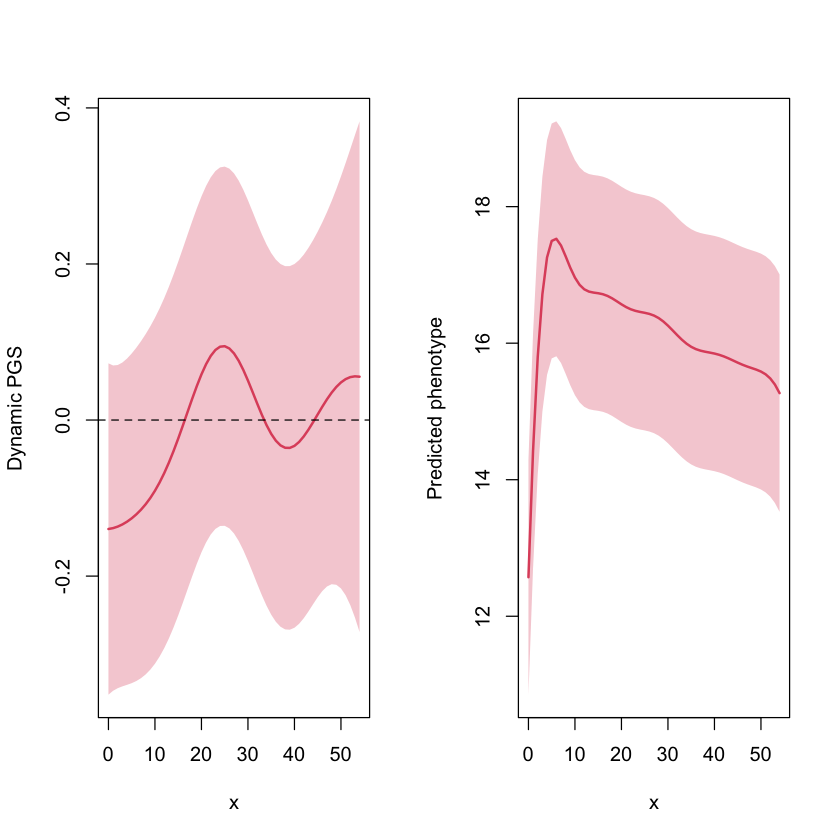

In [43]:
#　plotting the PGS with its standard error
par(mfcol=c(1,2))
plot(adata_pgs,i=1); abline(h=0,lty=2) # only PGS for the first individual
plot(adata_pgs,Pred=T) # PGS + population average

In [26]:
# comparison to the linear mixed model with age/age^2 interactions
# linear QTL effect (effect varies linearly across time)
mapid=match(adata$iid,adata$Lmat[,2])
covs = read.table("MockData/covariates.tsv",header=T)
xc=scale(adata$x)
res_linear <- do.call("rbind", parallel::mclapply(1:1000, function(i){
    dat <- data.frame(y = adata$y, xc = xc, g1 = as.numeric(G[i, mapid]), iid = adata$iid, covs)
    fit0 <- lme4::lmer(y ~ xc + pc1 + pc2 + sex + (1 + xc | iid), data = dat, REML = FALSE)
    fit1 <- lme4::lmer(y ~ g1 * xc + pc1 + pc2 + sex + (1 + xc | iid), data = dat, REML = FALSE)
    out <- anova(fit0, fit1)[2,]
    data.frame(variant=rownames(G)[i], out, check.names=FALSE)
}, mc.cores=4))
# quadratic QTL effect (effect varies quadratically across time)
xc2=scale(adata$x)^2
res_quad <- do.call("rbind", parallel::mclapply(1:1000, function(i){
    dat <- data.frame(y = adata$y, xc = xc, g1 = as.numeric(G[i, mapid]), iid = adata$iid, covs)
    fit0 <- lme4::lmer(y ~ xc + xc2 + pc1 + pc2 + sex + (1 + xc + xc2 | iid), data = dat, REML = FALSE)
    fit1 <- lme4::lmer(y ~ g1 * xc + g1 * xc2 + pc1 + pc2 + sex + (1 + xc + xc2 | iid), data = dat, REML = FALSE)
    out <- anova(fit0, fit1)[2,]
    data.frame(variant=rownames(G)[i], out, check.names=FALSE)
}, mc.cores=2))

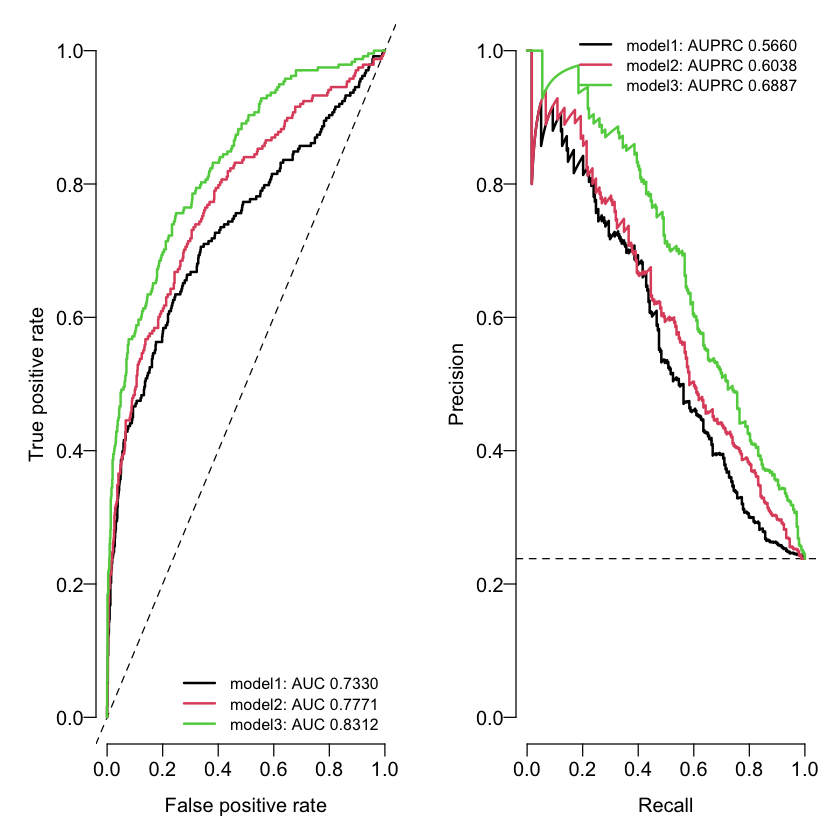

In [37]:
# comparison among linear, quadratic and full GP mapping 
# showing the hightest sensitivity and specificity using the GP approach
plotROCandPRC(cbind(res_linear[,9],res_quad[,9],adata$pval),isalt)